In [3]:

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load the CIFAR-10 dataset it contains 60000 images in 10 classes 
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 58s 0us/step


In [8]:
X_test.shape

(10000, 32, 32, 3)

In [ ]:
X_train.shape # 5000 images, each image is 32x32 pixels and has 3 color channels (RGB)

(50000, 32, 32, 3)

In [10]:
y_train.shape

(50000, 1)

In [ ]:
y_train[:5] #show the first 5 labels of the training set

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [ ]:
y_train = y_train.reshape(-1,) # reshape the labels to be a 1D array instead of a 2D array with one column
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [15]:
y_test = y_test.reshape(-1,)

In [16]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

In [17]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

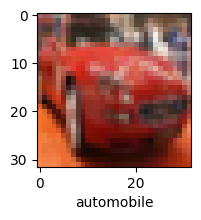

In [18]:
plot_sample(X_train, y_train, 5)

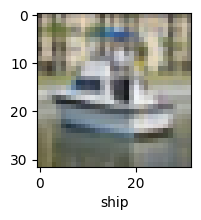

In [28]:
plot_sample(X_train, y_train, 501)

In [ ]:
# Normalize the pixel values to be between 0 and 1 by dividing by 255.0
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
# Build the ANN model (Artificial Neural Network)
ann = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model using Stochastic Gradient Descent (SGD) optimizer, sparse categorical crossentropy loss function and accuracy metric
ann.compile(optimizer='SGD',
            loss='sparse_categorical_crossentropy', 
            metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

C:\Users\Pc\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10226s 7s/step - accuracy: 0.3542 - loss: 1.8110
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 117s 75ms/step - accuracy: 0.4289 - loss: 1.6233
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 105s 67ms/step - accuracy: 0.4594 - loss: 1.5383
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.4825 - loss: 1.4789
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 94s 60ms/step - accuracy: 0.4980 - loss: 1.4291


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print('Classification report:\n', classification_report(y_test, y_pred_classes))
# precision - how many of the predicted positive cases were actually positive
# recall - how many of the actual positive cases were correctly predicted
# f1-score - the harmonic mean of precision and recall
# support - the number of actual occurrences of the class in the dataset

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Classification report:
               precision    recall  f1-score   support

           0       0.46      0.57      0.51      1000
           1       0.50      0.73      0.60      1000
           2       0.44      0.26      0.33      1000
           3       0.40      0.20      0.26      1000
           4       0.48      0.38      0.43      1000
           5       0.38      0.44      0.41      1000
           6       0.50      0.57      0.53      1000
           7       0.72      0.39      0.50      1000
           8       0.48      0.74      0.58      1000
           9       0.50      0.51      0.50      1000

    accuracy                           0.48     10000
   macro avg       0.49      0.48      0.46     10000
weighted avg       0.49      0.48      0.46     10000



In [32]:
import seaborn as sns

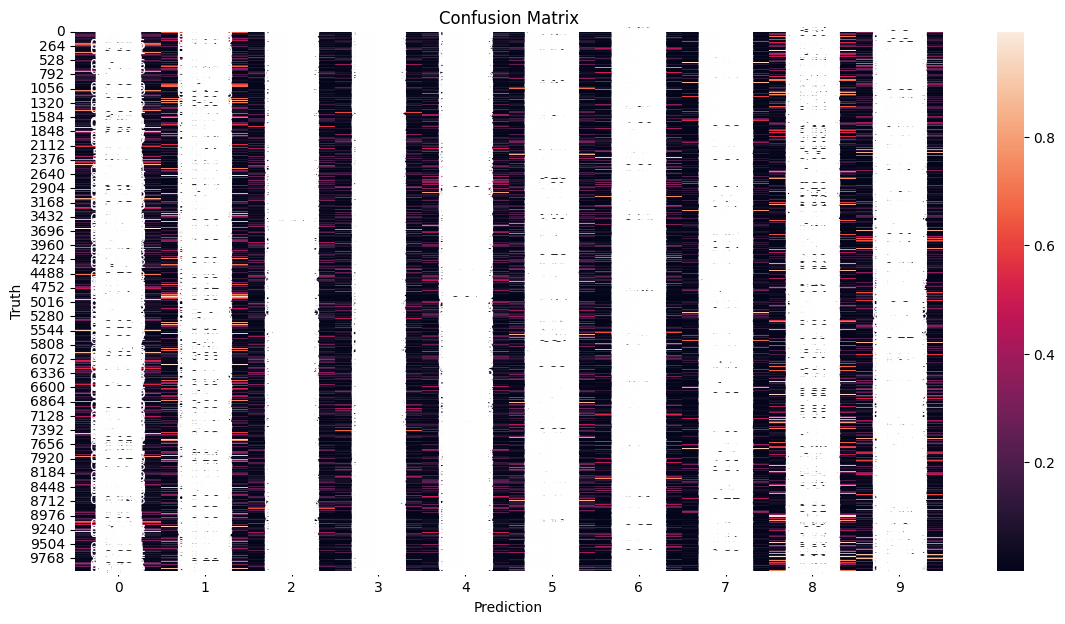

In [33]:
plt.figure(figsize=(14,7))
sns.heatmap(y_pred, annot=True)
plt.ylabel('Truth')
plt.xlabel('Prediction')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
cnn = models.Sequential([
    # Add a convolutional layer with 32 filters, a kernel size of 3x3, and ReLU activation function. The input shape is (32, 32, 3) which corresponds to the dimensions of the images in the CIFAR-10 dataset.
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Add another convolutional layer with 64 filters and a kernel size of 3x3, followed by a max pooling layer with a pool size of 2x2
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Add a flatten layer to convert the 2D feature maps into a 1D vector, followed by a dense layer with 64 units and ReLU activation function, and an output layer with 10 units and softmax activation function for multi-class classification.
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\Pc\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy', 
            metrics=['accuracy'])
            

In [36]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.4860 - loss: 1.4246
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6239 - loss: 1.0760
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6675 - loss: 0.9574
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6977 - loss: 0.8686
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7202 - loss: 0.8046
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7387 - loss: 0.7507
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - accuracy: 0.7572 - loss: 0.6995
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7707 - loss: 0.6556
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7860 - loss: 0.6139
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7982 - loss: 0.5740


In [37]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7037 - loss: 0.9191


[0.9190713763237, 0.7037000060081482]

In [38]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


array([[1.2432657e-03, 1.4585654e-03, 3.4632059e-04, 9.0897268e-01,
        2.5618571e-04, 1.5842486e-02, 9.8950164e-05, 9.0539215e-06,
        7.1539663e-02, 2.3282372e-04],
       [9.7127503e-04, 8.8924374e-03, 1.0199834e-08, 7.0747928e-09,
        1.4799986e-09, 2.6397101e-10, 4.1656338e-11, 2.2670037e-10,
        9.8984164e-01, 2.9464028e-04],
       [3.8673300e-02, 6.6922683e-01, 1.2550635e-04, 2.3317678e-04,
        1.3631773e-04, 1.1150693e-05, 2.5211362e-05, 9.6373973e-05,
        2.3754483e-01, 5.3927224e-02],
       [9.6277452e-01, 4.2485432e-03, 2.9894388e-03, 1.2086150e-04,
        9.5411076e-04, 4.2800602e-06, 9.2319482e-05, 2.3955126e-06,
        2.8724831e-02, 8.8739951e-05],
       [1.6800367e-06, 6.7049528e-05, 3.7733138e-02, 3.2635506e-02,
        3.1459653e-01, 5.5933092e-03, 6.0934651e-01, 1.5760952e-05,
        6.5268641e-06, 4.0139462e-06]], dtype=float32)

In [41]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(1), np.int64(0), np.int64(6)]

In [40]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

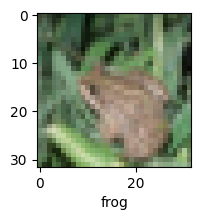

In [45]:
plot_sample(X_test, y_test, 4)

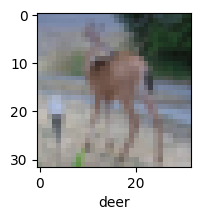

In [43]:
plot_sample(X_test, y_test, 100)

In [46]:
classes[y_classes[60]]

'horse'

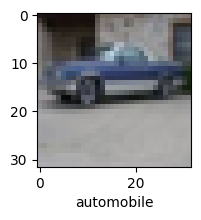

In [47]:
plot_sample(X_train, y_train, 10000)